### Obtain

In [70]:
#polars
#fastexcel
#numpy
#seaborn
#matplotib
#scikit-learn
#pandas
#pyarrow

In [71]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

In [72]:
df_prim = pl.read_excel(
    "datasets/02_ROTURAS_RED_PRIMARIA_SECUNDARIA_PIURA.xlsx",
    sheet_name="ROTURAS_RED_PRIMARIA",
)
df_sec = pl.read_excel(
    "datasets/02_ROTURAS_RED_PRIMARIA_SECUNDARIA_PIURA.xlsx",
    sheet_name="FUGAS_RED_SECUNDARIA",
)
df_red = pl.read_excel("datasets/03_REDES_CONEXIONES_PIURA.xlsx")
df_cau = pl.read_excel("datasets/01_BASE_CAUDALES_SECTORES_PIURA.xlsx")

## Reto 1

###  Inconsistencias geográficas

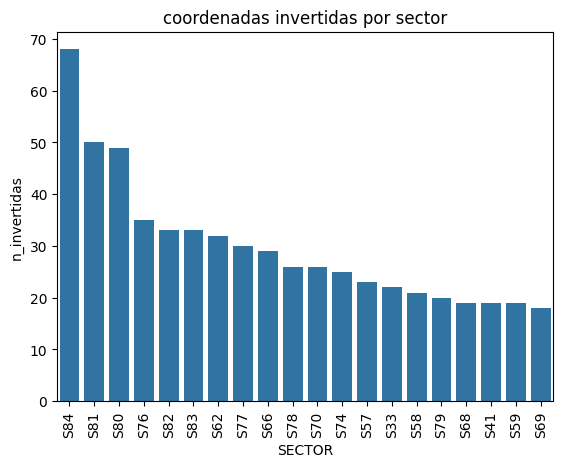

In [73]:
# conteo de coordenadas invertidas
inv_prim = df_prim.filter(pl.col('latitud') < -20).group_by('SECTOR').agg(pl.len().alias('n_invertidas')).with_columns(pl.lit('roturas').alias('tipo'))
inv_sec = df_sec.filter(pl.col('latitud') < -20).group_by('SECTOR').agg(pl.len().alias('n_invertidas')).with_columns(pl.lit('fugas').alias('tipo'))
df_coord_inv = pl.concat([inv_prim, inv_sec]).sort('n_invertidas', descending=True)

# grafico
sns.barplot(data=df_coord_inv.head(20).to_pandas(), x='SECTOR', y='n_invertidas')
plt.title('coordenadas invertidas por sector')
plt.xticks(rotation=90)
plt.show()

In [74]:
def corregir_coord(df):
    return df.with_columns([
        pl.when(pl.col('latitud') < -20).then(pl.col('longitud')).otherwise(pl.col('latitud')).alias('lat_corr'),
        pl.when(pl.col('latitud') < -20).then(pl.col('latitud')).otherwise(pl.col('longitud')).alias('lon_corr')
    ]).drop(['latitud', 'longitud']).rename({'lat_corr': 'latitud', 'lon_corr': 'longitud'})

df_prim_c = corregir_coord(df_prim)
df_sec_c = corregir_coord(df_sec)

### Sobreregistro de datos

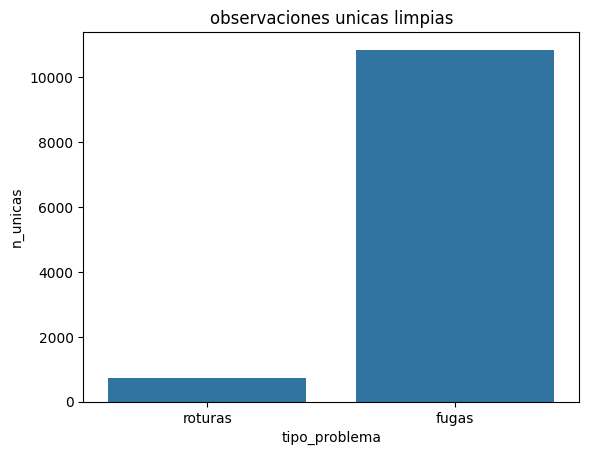

In [75]:
df_prim_limpia = df_prim_c.unique(subset=['CONEXION', 'CATEGORIA', 'fecha_inicio'], keep='first')
df_sec_limpia = df_sec_c.unique(subset=['CONEXION', 'CATEGORIA', 'fecha_inicio'], keep='first')

# tabla de observaciones unicas para excel
df_obs_unicas = pl.DataFrame({
    'tipo_problema': ['roturas', 'fugas'],
    'n_unicas': [df_prim_limpia.height, df_sec_limpia.height]
})

# grafico de observaciones despues de limpieza
sns.barplot(data=df_obs_unicas.to_pandas(), x='tipo_problema', y='n_unicas')
plt.title('observaciones unicas limpias')
plt.show()

## Reto 2: Consolidación de información a nivel de sector

### Ranking de roturas y fugas por sector

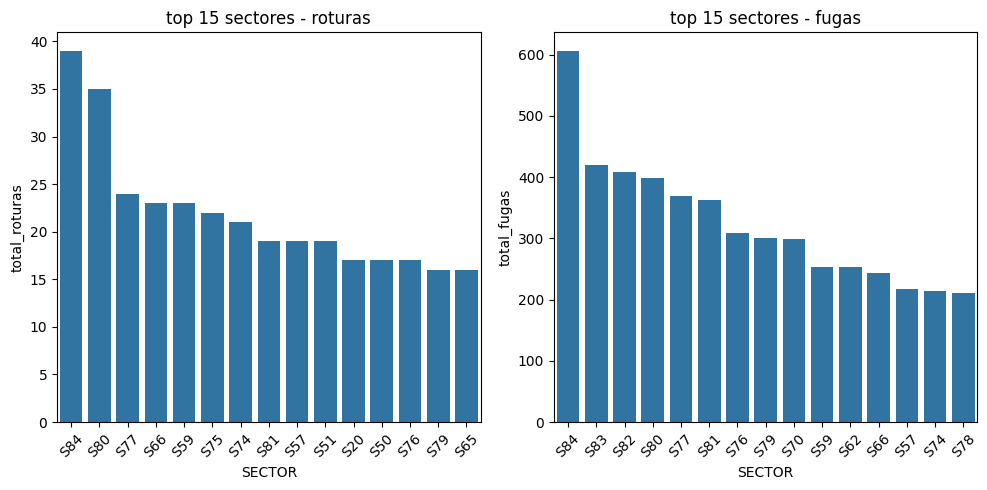

In [76]:
rank_prim = df_prim_limpia.group_by('SECTOR').agg(pl.len().alias('total_roturas')).sort('total_roturas', descending=True)
rank_sec = df_sec_limpia.group_by('SECTOR').agg(pl.len().alias('total_fugas')).sort('total_fugas', descending=True)

# grafico (top 15 sectores)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=rank_prim.head(15).to_pandas(), x='SECTOR', y='total_roturas', ax=axes[0])
axes[0].set_title('top 15 sectores - roturas')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(data=rank_sec.head(15).to_pandas(), x='SECTOR', y='total_fugas', ax=axes[1])
axes[1].set_title('top 15 sectores - fugas')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Cálculo del tiempo de reparación

In [77]:
# calculo del tiempo de reparacion
def calc_tiempo_reparacion(df):
    return df.with_columns([
        pl.col('hora_inicio').cast(pl.Utf8).str.extract(r"(\d{2}:\d{2}:\d{2})").alias('h_i'),
        pl.col('hora_fin').cast(pl.Utf8).str.extract(r"(\d{2}:\d{2}:\d{2})").alias('h_f')
    ]).with_columns([
        (pl.col('fecha_inicio').cast(pl.Utf8) + " " + pl.col('h_i')).str.strptime(pl.Datetime, format='%Y-%m-%d %H:%M:%S', strict=False).alias('dt_inicio'),
        (pl.col('fecha_fin').cast(pl.Utf8) + " " + pl.col('h_f')).str.strptime(pl.Datetime, format='%Y-%m-%d %H:%M:%S', strict=False).alias('dt_fin')
    ]).with_columns(
        ((pl.col('dt_fin') - pl.col('dt_inicio')).dt.total_seconds() / 3600).alias('tiempo_reparacion_hrs')
    ).drop_nulls('tiempo_reparacion_hrs')

t_prim = calc_tiempo_reparacion(df_prim_limpia)
t_sec = calc_tiempo_reparacion(df_sec_limpia)

# promedios de reparacion por sector
t_prom_prim = t_prim.group_by('SECTOR').agg(pl.col('tiempo_reparacion_hrs').mean().alias('promedio_reparacion'))
t_prom_sec = t_sec.group_by('SECTOR').agg(pl.col('tiempo_reparacion_hrs').mean().alias('promedio_reparacion'))

# promedios totales
prom_tot_prim = t_prim.select(pl.col('tiempo_reparacion_hrs').mean()).item()
prom_tot_sec = t_sec.select(pl.col('tiempo_reparacion_hrs').mean()).item()

# agregar fila total
t_prom_prim = pl.concat([t_prom_prim, pl.DataFrame({'SECTOR': ['TOTAL'], 'promedio_reparacion': [prom_tot_prim]})])
t_prom_sec = pl.concat([t_prom_sec, pl.DataFrame({'SECTOR': ['TOTAL'], 'promedio_reparacion': [prom_tot_sec]})])

In [78]:

df2_prim = df_prim_limpia.with_columns(
    datetime_inicio=pl.col("fecha_inicio").dt.combine(pl.col("hora_inicio").dt.time()),
    datetime_fin=pl.col("fecha_fin").dt.combine(pl.col("hora_fin").dt.time()),
)
df2_prim = df2_prim.with_columns(
    duracion=pl.col("datetime_fin") - pl.col("datetime_inicio")
)
df2_prim = df2_prim.drop(["fecha_inicio", "hora_inicio", "fecha_fin", "hora_fin"])

df2_prim.head()


CONEXION,SECTOR,CDESTIPSER,MES,AÑO,CATEGORIA,latitud,longitud,datetime_inicio,datetime_fin,duracion
i64,str,str,i64,i64,str,f64,f64,datetime[μs],datetime[μs],duration[μs]
994,"""S80""","""AG: Conexiones Domiciliarias …",7,2025,"""Rotura Tuberia Matriz""",-5.190051,-80.590597,2025-07-24 10:01:00,2025-07-25 07:19:11.750,21h 18m 11s 750ms
8891,"""S84""","""AG: Conexiones Domiciliarias …",1,2025,"""Rotura Tuberia Matriz""",-5.17281,-80.651452,2025-01-31 04:01:00,2025-02-03 13:52:22.552,3d 9h 51m 22s 552ms
2152,"""S41""","""AG: Conexiones Domiciliarias …",5,2025,"""Rotura Tuberia Matriz""",-5.198672,-80.625481,2025-05-06 17:01:00,2025-05-10 19:01:59.976,4d 2h 59s 976ms
9178,"""S84""","""AG: Conexiones Domiciliarias …",3,2025,"""Rotura Tuberia Matriz""",-5.141983,-80.634926,2025-03-07 02:01:00,2025-03-08 20:37:09.376,1d 18h 36m 9s 376ms
6935,"""S40""","""AG: Conexiones Domiciliarias …",6,2025,"""Rotura Tuberia Matriz""",-5.191619,-80.599777,2025-06-08 04:01:00,2025-06-10 22:07:14.640,2d 18h 6m 14s 640ms


### Normalización de casos

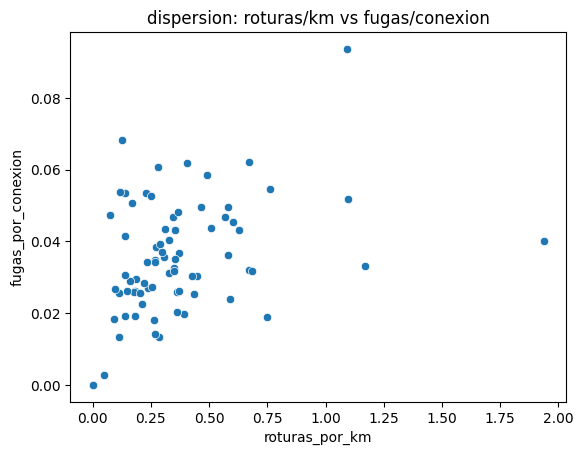

In [79]:
df_red_c = df_red.rename({"Conexiones": "conexiones", "red_distribucion": "red_dist_m"})
df_norm = rank_prim.join(rank_sec, on='SECTOR', how='full').fill_null(0).join(df_red_c, on='SECTOR', how='left').fill_null(0)

df_norm = df_norm.with_columns([
    pl.when(pl.col('red_dist_m') > 0).then(pl.col('total_roturas') / (pl.col('red_dist_m') / 1000)).otherwise(0.0).alias('roturas_por_km'),
    pl.when(pl.col('conexiones') > 0).then(pl.col('total_fugas') / pl.col('conexiones')).otherwise(0.0).alias('fugas_por_conexion')
])

# grafico
sns.scatterplot(data=df_norm.to_pandas(), x='roturas_por_km', y='fugas_por_conexion')
plt.title('dispersion: roturas/km vs fugas/conexion')
plt.show()

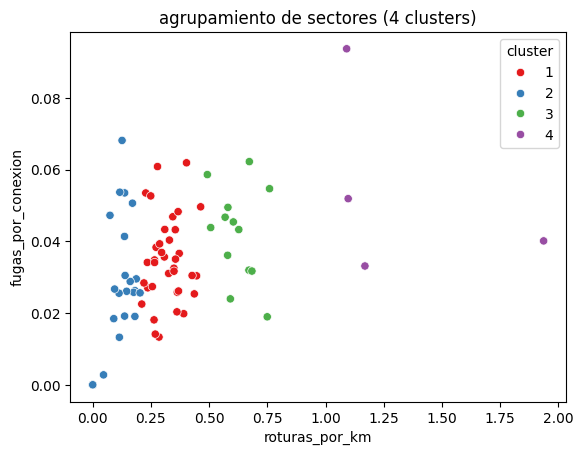

In [80]:
x_cluster = df_norm.select(['roturas_por_km', 'fugas_por_conexion']).to_numpy()
kmeans = KMeans(n_clusters=4, random_state=42)
grupos = kmeans.fit_predict(x_cluster) + 1

df_norm = df_norm.with_columns(pl.Series('cluster', grupos))

# grafico
sns.scatterplot(data=df_norm.to_pandas(), x='roturas_por_km', y='fugas_por_conexion', hue='cluster', palette='Set1')
plt.title('agrupamiento de sectores (4 clusters)')
plt.show()